# M2.Ex2: Automobile Fuel Efficiency

### Name: Shaima Alqahtani

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M2/exercises/ex1_multi-reg.ipynb)

In [33]:
import pandas as pd
import sklearn

## Auto MPG Dataset

The Auto MPG Dataset is a classic benchmark for regression analysis in machine learning. It originally appeared in the 1983 American Statistical Association (ASA) Exposition and was later donated to the UCI Machine Learning Repository by Ross Quinlan in 1993.

The data consists of technical specifications for various car models from the late 1970s and early 1980s, primarily used to predict fuel efficiency (MPG).

- Features: `5` numerical, `3` categorical
- Target: `mpg` (miles per gallon)
- Size: `398` samples
- Source: [Auto MPG Dataset](https://archive.ics.uci.edu/dataset/9/auto+mpg)

### Step 1. Load the data

In [34]:
df = pd.read_csv("../../../datasets/auto-mpg.csv")
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86,2790,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52,2130,24.6,82,2,vw pickup
395,32.0,4,135.0,84,2295,11.6,82,1,dodge rampage
396,28.0,4,120.0,79,2625,18.6,82,1,ford ranger


### Step 2.a Assign variables `X` to the features and `y` to the target

In [35]:
y = df["mpg"]
X = df.drop(columns=["mpg"])

### Step 2.b print the type of each

In [36]:
print(type(X))
print(type(y))

<class 'pandas.DataFrame'>
<class 'pandas.Series'>


### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

In [37]:
print("Target type: numerical (continuous)")
print("Task type: regression")

Target type: numerical (continuous)
Task type: regression


### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [38]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (398, 8)
y shape: (398,)


### Step 4. Summarize the distribution of the data

- Use `describe()` for numerical features
- Use `describe()` for cateogrical features

In [39]:
num_features = X.select_dtypes(include=["int64", "float64"]).columns
cat_features = X.select_dtypes(include=["object", "category"]).columns

print("Numerical features:", list(num_features))
print("Categorical features:", list(cat_features))

print("\nNumerical features summary:")
print(X[num_features].describe())

print("\nCategorical features summary:")
print(X[cat_features].describe())

Numerical features: ['cylinders', 'displacement', 'weight', 'acceleration', 'model year', 'origin']
Categorical features: ['horsepower', 'car name']

Numerical features summary:
        cylinders  displacement       weight  acceleration  model year  \
count  398.000000    398.000000   398.000000    398.000000  398.000000   
mean     5.454774    193.425879  2970.424623     15.568090   76.010050   
std      1.701004    104.269838   846.841774      2.757689    3.697627   
min      3.000000     68.000000  1613.000000      8.000000   70.000000   
25%      4.000000    104.250000  2223.750000     13.825000   73.000000   
50%      4.000000    148.500000  2803.500000     15.500000   76.000000   
75%      8.000000    262.000000  3608.000000     17.175000   79.000000   
max      8.000000    455.000000  5140.000000     24.800000   82.000000   

           origin  
count  398.000000  
mean     1.572864  
std      0.802055  
min      1.000000  
25%      1.000000  
50%      1.000000  
75%      2.0000

C:\Users\Dell\AppData\Local\Temp\ipykernel_25112\1251682848.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = X.select_dtypes(include=["object", "category"]).columns


### Step 5. Plot each of the features vs the target

Hint use this: `sns.pairplot(adv,x_vars=['TV','Radio','Newspaper'],y_vars='Sales',height=6,aspect=0.7,kind='reg')`

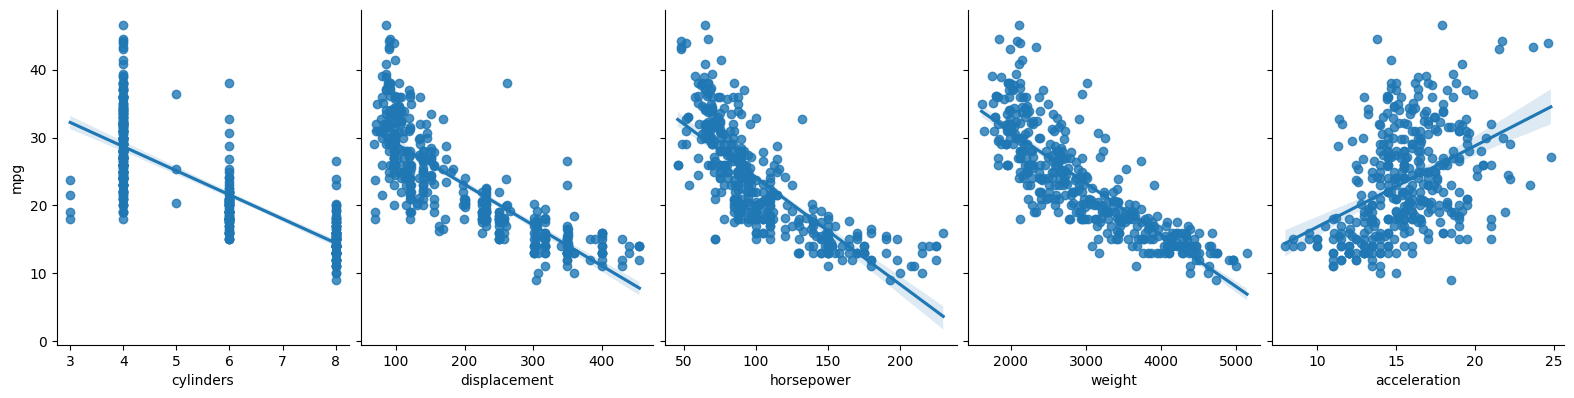

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

df[num_for_plot] = df[num_for_plot].apply(pd.to_numeric, errors="coerce")
df = df.dropna()

sns.pairplot(
    pd.concat([df[num_for_plot], df["mpg"]], axis=1),
    x_vars=num_for_plot,
    y_vars="mpg",
    height=4,
    aspect=0.8,
    kind="reg"
)
plt.show()

### Step 6. What is the relationship between the feature and the target? (increasing or decreasing or none)

1. `x=cylinders` and `y=mpg`
2. `x=displacement` and `y=mpg`
3. `x=horsepower` and `y=mpg`
4. `x=weight` and `y=mpg`
5. `x=acceleration` and `y=mpg`

In [41]:
print("1. cylinders vs mpg: decreasing (more cylinders → lower mpg).")
print("2. displacement vs mpg: decreasing (larger engines → lower mpg).")
print("3. horsepower vs mpg: decreasing (more power → lower mpg).")
print("4. weight vs mpg: decreasing (heavier cars → lower mpg).")
print("5. acceleration vs mpg: weak relationship, slightly increasing or unclear.")

1. cylinders vs mpg: decreasing (more cylinders → lower mpg).
2. displacement vs mpg: decreasing (larger engines → lower mpg).
3. horsepower vs mpg: decreasing (more power → lower mpg).
4. weight vs mpg: decreasing (heavier cars → lower mpg).
5. acceleration vs mpg: weak relationship, slightly increasing or unclear.


### Step 7. Define the pipeline with pre-processing steps

Raw data is rarely ready for use in ML models. We often need steps such as:

- Handling missing values
- Encoding categorical variables
- Scaling numerical variables

Use `ColumnTransformer` to separate the preprocessing steps of the numerical features from the categorical ones.


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression

num_features = X.select_dtypes(include=["int64", "float64"]).columns
cat_features = X.select_dtypes(include=["object", "category"]).columns

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_features),
        ("cat", categorical_transformer, cat_features),
    ]
)

predictor = LinearRegression()

pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", predictor),
    ]
)

C:\Users\Dell\AppData\Local\Temp\ipykernel_25112\662415574.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = X.select_dtypes(include=["object", "category"]).columns


### Step 8. Split the dataset into train and test sets

In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (318, 8)
X_test shape: (80, 8)
y_train shape: (318,)
y_test shape: (80,)


### Step 9.a Fit the pipeline on the training set

In [45]:
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

### Step 9.b Identify the learned coefficients (for each feature) and the bias term

In [ ]:
reg = pipe.named_steps["regressor"]

num_feature_names = list(num_features)

cat_feature_names = list(
    pipe.named_steps["preprocessor"]
        .named_transformers_["cat"]
        .named_steps["onehot"]
        .get_feature_names_out(cat_features)
)

all_feature_names = num_feature_names + cat_feature_names

print("Number of features after preprocessing:", len(all_feature_names))
print("Number of coefficients:", len(reg.coef_))

for name, coef in zip(all_feature_names, reg.coef_):
    print(f"{name}: {coef:.4f}")

print(f"\nIntercept (bias): {reg.intercept_:.4f}")

Number of features after preprocessing: 342
Number of coefficients: 342
cylinders: -3.4680
displacement: -9.9552
weight: 10.0984
acceleration: -4.7753
model year: 1.7477
origin: 1.1002
horsepower_100: -2.9349
horsepower_102: -7.5664
horsepower_103: -4.7249
horsepower_105: -2.5646
horsepower_108: -3.0084
horsepower_110: -3.3557
horsepower_112: -6.2500
horsepower_113: -0.8033
horsepower_115: -0.6020
horsepower_116: -4.0375
horsepower_120: -7.0536
horsepower_122: -2.5327
horsepower_125: -0.6043
horsepower_129: -1.8855
horsepower_130: -5.0915
horsepower_132: -1.2433
horsepower_133: -7.7709
horsepower_135: 0.1840
horsepower_137: -4.5623
horsepower_138: -1.5513
horsepower_139: 0.0268
horsepower_140: -5.1042
horsepower_142: 1.0429
horsepower_145: -5.9442
horsepower_148: -4.7434
horsepower_149: -2.4765
horsepower_150: -7.5723
horsepower_152: -5.7996
horsepower_153: -2.0582
horsepower_155: -17.5375
horsepower_158: -2.0998
horsepower_160: -5.6467
horsepower_165: -3.5557
horsepower_170: -5.1334
h

### Step 9.c how much `mpg` we gain if we decrease the weight of the automobile by `100kg`?

In [50]:
sample = X_train.mean(numeric_only=True).to_frame().T

for col in cat_features:
    sample[col] = X_train[col].mode()[0]

sample = sample[X_train.columns]

pred_original = pipe.predict(sample)[0]

sample_weight_minus = sample.copy()
sample_weight_minus["weight"] = sample_weight_minus["weight"] - 100

pred_weight_minus = pipe.predict(sample_weight_minus)[0]

delta_mpg = pred_weight_minus - pred_original

print(f"Approximate mpg gain when decreasing weight by 100 units: {delta_mpg:.3f}")


Approximate mpg gain when decreasing weight by 100 units: -1.203


### Step 10. Evaluate the pipeline on the test set

In [49]:
score = pipe.score(X_test, y_test)
print(f"Pipeline R^2 on test set: {score:.4f}")

Pipeline R^2 on test set: 0.1741
